In [2]:
import pandas as pd
import numpy as np

# Set seed for reproducible data
np.random.seed(42)

# Set dataset size
num_samples = 1000

# Sample Metadata
artists_list = [
    'The Weeknd', 'Taylor Swift', 'Drake', 'Bad Bunny', 'Dua Lipa', 
    'Ed Sheeran', 'Ariana Grande', 'Post Malone', 'Billie Eilish', 'BTS',
    'Kendrick Lamar', 'Coldplay', 'Olivia Rodrigo', 'Harry Styles', 'Doja Cat'
]

genres_list = ['pop', 'hip-hop', 'rock', 'dance/electronic', 'r&b', 'indie', 'latin']
album_types = ['album', 'single']

# 1. Generate Metadata
track_ids = [f"track_{str(i).zfill(5)}" for i in range(1, num_samples + 1)]
track_names = [f"Song Title {i}" for i in range(1, num_samples + 1)]
artists = np.random.choice(artists_list, size=num_samples)
genres = np.random.choice(genres_list, size=num_samples)
album_types_choice = np.random.choice(album_types, size=num_samples, p=[0.7, 0.3])
explicit = np.random.choice([0, 1], size=num_samples, p=[0.8, 0.2])

# 2. Generate Audio Features (bounded & standard ranges)
# Danceability & Valence (0.0 to 1.0)
danceability = np.clip(np.random.beta(a=5, b=2, size=num_samples), 0, 1)
valence = np.clip(np.random.beta(a=3, b=3, size=num_samples), 0, 1)

# Energy & Loudness (Energetic songs tend to be louder)
energy = np.clip(np.random.beta(a=4, b=2, size=num_samples), 0, 1)
loudness = -20 + (energy * 16) + np.random.normal(0, 2, size=num_samples) # dB range approx -20 to 0

# Tempo (BPM typically 60 to 180)
tempo = np.random.normal(loc=120, scale=25, size=num_samples)
tempo = np.clip(tempo, 60, 200)

# Acousticness & Speechiness
acousticness = np.clip(np.random.beta(a=1, b=4, size=num_samples), 0, 1)
speechiness = np.clip(np.random.exponential(scale=0.08, size=num_samples), 0, 0.95)

# Duration in milliseconds (2 to 5 minutes)
duration_ms = np.random.normal(loc=210000, scale=35000, size=num_samples).astype(int)
duration_ms = np.clip(duration_ms, 120000, 360000)

# Musical Key (0 to 11) & Mode (0 = Minor, 1 = Major)
key = np.random.randint(0, 12, size=num_samples)
mode = np.random.choice([0, 1], size=num_samples, p=[0.35, 0.65])

# 3. Generate Realistic Target Variable: Popularity (0 to 100)
# Formula gives higher popularity to high energy/danceability and shorter duration
raw_popularity = (
    (danceability * 25) + 
    (energy * 20) + 
    (1 - acousticness) * 15 + 
    np.random.normal(25, 12, size=num_samples)
)
popularity = np.clip(raw_popularity, 0, 100).astype(int)

# 4. Construct DataFrame
df = pd.DataFrame({
    'track_id': track_ids,
    'track_name': track_names,
    'artist': artists,
    'genre': genres,
    'album_type': album_types_choice,
    'popularity': popularity,
    'duration_ms': duration_ms,
    'explicit': explicit,
    'danceability': np.round(danceability, 3),
    'energy': np.round(energy, 3),
    'key': key,
    'loudness': np.round(loudness, 2),
    'mode': mode,
    'speechiness': np.round(speechiness, 3),
    'acousticness': np.round(acousticness, 3),
    'valence': np.round(valence, 3),
    'tempo': np.round(tempo, 1)
})

# Save to CSV
df.to_csv('spotify_tracks.csv', index=False)
print("Dataset created successfully! Saved as 'spotify_tracks.csv'")
print(df.head())

Dataset created successfully! Saved as 'spotify_tracks.csv'
      track_id    track_name          artist             genre album_type  \
0  track_00001  Song Title 1   Ariana Grande               pop     single   
1  track_00002  Song Title 2       Bad Bunny              rock     single   
2  track_00003  Song Title 3  Olivia Rodrigo               r&b     single   
3  track_00004  Song Title 4        Doja Cat               r&b      album   
4  track_00005  Song Title 5  Kendrick Lamar  dance/electronic      album   

   popularity  duration_ms  explicit  danceability  energy  key  loudness  \
0          70       264051         0         0.596   0.695    5     -7.37   
1          80       245955         0         0.697   0.426    2    -13.45   
2          68       153985         0         0.643   0.744    4     -9.13   
3          60       260564         0         0.774   0.832    9     -8.18   
4          69       171144         1         0.834   0.695    7    -11.90   

   mode  speec

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   track_id      1000 non-null   object 
 1   track_name    1000 non-null   object 
 2   artist        1000 non-null   object 
 3   genre         1000 non-null   object 
 4   album_type    1000 non-null   object 
 5   popularity    1000 non-null   int64  
 6   duration_ms   1000 non-null   int64  
 7   explicit      1000 non-null   int64  
 8   danceability  1000 non-null   float64
 9   energy        1000 non-null   float64
 10  key           1000 non-null   int32  
 11  loudness      1000 non-null   float64
 12  mode          1000 non-null   int64  
 13  speechiness   1000 non-null   float64
 14  acousticness  1000 non-null   float64
 15  valence       1000 non-null   float64
 16  tempo         1000 non-null   float64
dtypes: float64(7), int32(1), int64(4), object(5)
memory usage: 129.0+ KB


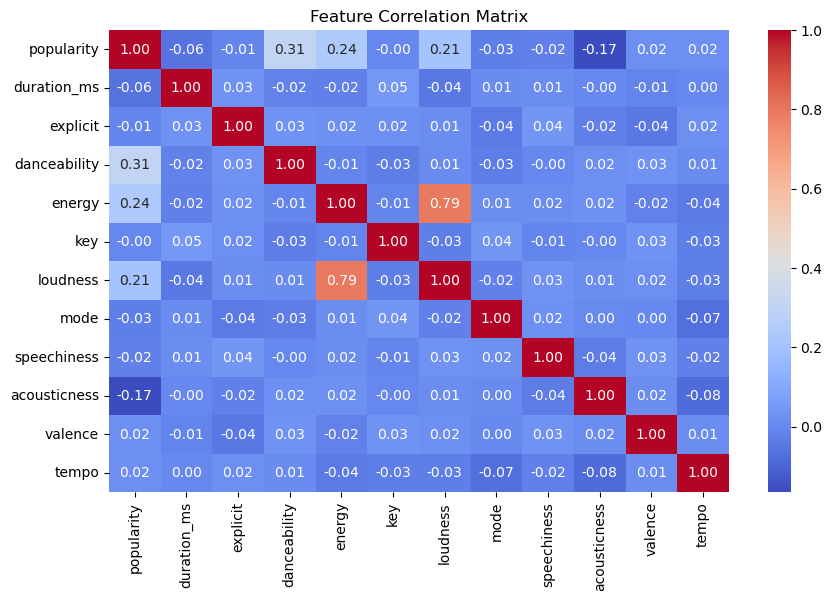

In [3]:
# General info and data types
df.info()

# Summary statistics for numerical features
df.describe()

# Check for missing values
df.isnull().sum()

# Correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()

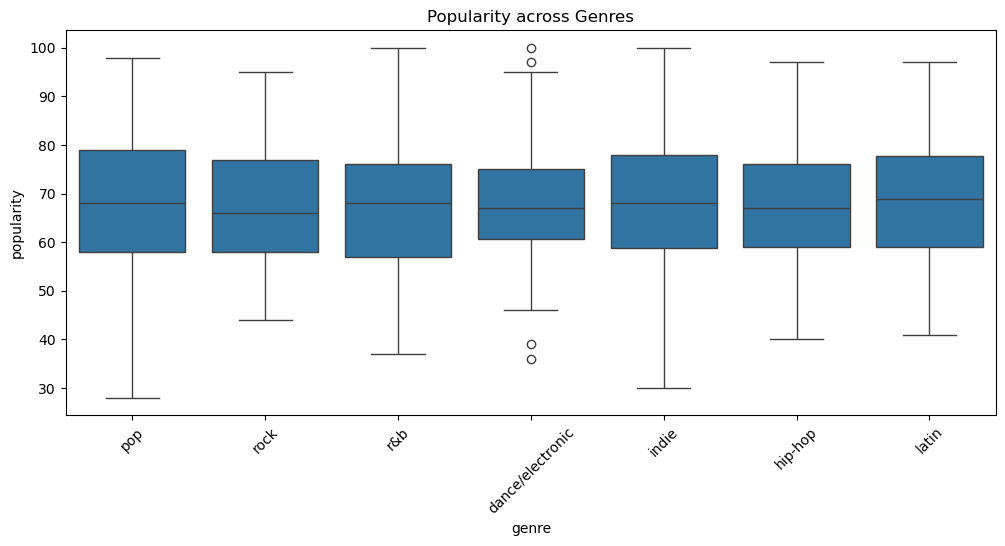

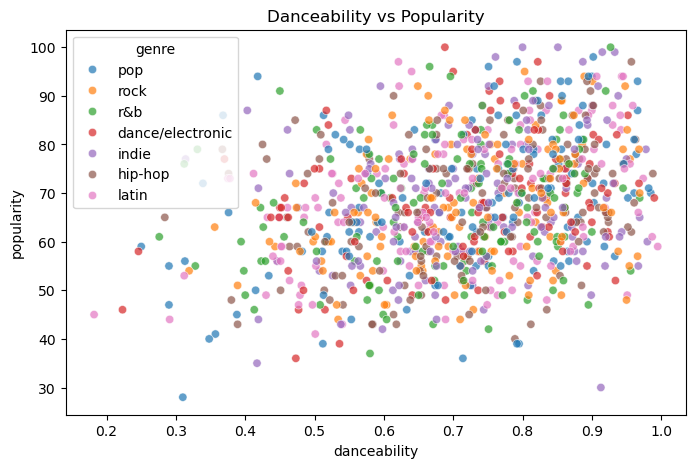

In [4]:
# Popularity distribution by Genre
plt.figure(figsize=(12, 5))
sns.boxplot(x='genre', y='popularity', data=df)
plt.xticks(rotation=45)
plt.title('Popularity across Genres')
plt.show()

# Danceability vs. Popularity
plt.figure(figsize=(8, 5))
sns.scatterplot(x='danceability', y='popularity', hue='genre', data=df, alpha=0.7)
plt.title('Danceability vs Popularity')
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Feature selection
features = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'valence', 'tempo', 'duration_ms', 'explicit', 'mode', 'key']
X = df[features]
y = df['popularity']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print(f"R² Score: {r2_score(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

R² Score: 0.01
RMSE: 12.24


In [6]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# Include 'genre' in features
numerical_features = ['danceability', 'energy', 'loudness', 'speechiness', 
                      'acousticness', 'valence', 'tempo', 'duration_ms', 'explicit', 'mode', 'key']
categorical_features = ['genre']

X = df[numerical_features + categorical_features]
y = df['popularity']

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

# Combine with model
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

# Fit and evaluate
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model_pipeline.fit(X_train, y_train)

y_pred = model_pipeline.predict(X_test)
print(f"New R² Score: {r2_score(y_test, y_pred):.2f}")
print(f"New RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

New R² Score: 0.01
New RMSE: 12.25


<Axes: xlabel='popularity', ylabel='Count'>

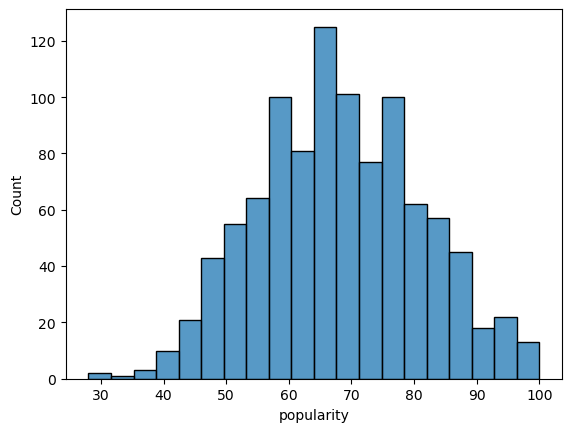

In [7]:
df['popularity'].value_counts()
# or
sns.histplot(df['popularity'], bins=20)

In [8]:
# Check which features the current Random Forest relied on most
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print("Feature Importances:\n", importances)

Feature Importances:
 danceability    0.197235
energy          0.157888
acousticness    0.123333
duration_ms     0.097284
loudness        0.096552
speechiness     0.091737
valence         0.086802
tempo           0.085973
key             0.045459
mode            0.010138
explicit        0.007598
dtype: float64


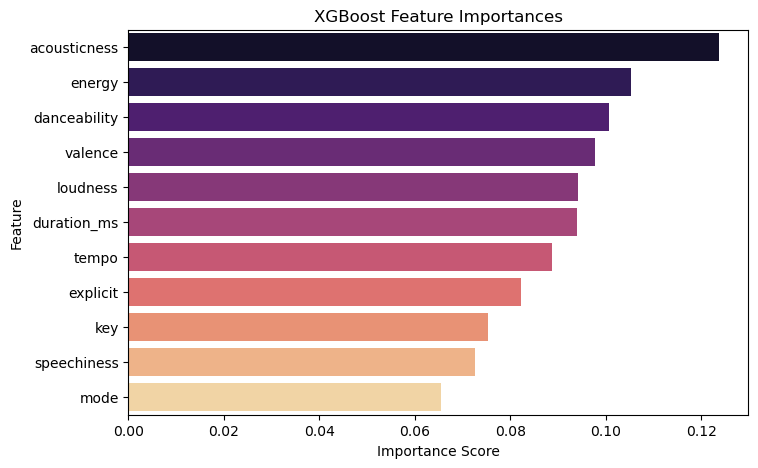

XGBoost MAE:  10.37
XGBoost RMSE: 13.03
XGBoost R²:   -0.12


In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# 1. Define feature columns strictly matching numeric data
features = ['danceability', 'energy', 'loudness', 'speechiness', 
            'acousticness', 'valence', 'tempo', 'duration_ms', 
            'key', 'mode', 'explicit']

# 2. Train XGBoost Model
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train[features], y_train)

# 3. Get and Plot Feature Importances
importances = pd.Series(xgb_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, legend=False, palette="magma")
plt.title("XGBoost Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

# 4. Evaluate Performance
y_pred = xgb_model.predict(X_test[features])
print(f"XGBoost MAE:  {mean_absolute_error(y_test, y_pred):.2f}")
print(f"XGBoost RMSE: {root_mean_squared_error(y_test, y_pred):.2f}")
print(f"XGBoost R²:   {r2_score(y_test, y_pred):.2f}")

In [12]:
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Tuned XGBoost Model to prevent overfitting
xgb_tuned = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,    # L1 Regularization
    reg_lambda=1.0,   # L2 Regularization
    random_state=42
)

# Fit tuned model
xgb_tuned.fit(X_train[features], y_train)

# Evaluate Performance
y_pred_tuned = xgb_tuned.predict(X_test[features])
print(f"Tuned MAE:  {mean_absolute_error(y_test, y_pred_tuned):.2f}")
print(f"Tuned RMSE: {root_mean_squared_error(y_test, y_pred_tuned):.2f}")
print(f"Tuned R²:   {r2_score(y_test, y_pred_tuned):.2f}")

Tuned MAE:  9.75
Tuned RMSE: 12.10
Tuned R²:   0.03


In [14]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Ensure Random Forest is fitted on the same numerical features
model = RandomForestRegressor(random_state=42)
model.fit(X_train[features], y_train)

# 2. Benchmark comparison table
rf_preds = model.predict(X_test[features])
xgb_preds = xgb_model.predict(X_test[features])
xgb_tuned_preds = xgb_tuned.predict(X_test[features])

results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost (Default)', 'XGBoost (Tuned)'],
    'MAE': [
        mean_absolute_error(y_test, rf_preds),
        mean_absolute_error(y_test, xgb_preds),
        mean_absolute_error(y_test, xgb_tuned_preds)
    ],
    'R² Score': [
        r2_score(y_test, rf_preds),
        r2_score(y_test, xgb_preds),
        r2_score(y_test, xgb_tuned_preds)
    ]
})

display(results)

,Model,MAE,R² Score
0,Random Forest,9.933050,0.014096
1,XGBoost (Default),10.372642,-0.119729
2,XGBoost (Tuned),9.751448,0.034470


In [16]:
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Define numeric features
numeric_cols = ['danceability', 'energy', 'loudness', 'speechiness', 
                'acousticness', 'valence', 'tempo', 'duration_ms', 
                'key', 'mode', 'explicit']

# 2. Automatically find string/categorical columns in df (excluding track names/IDs if present)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Print columns being encoded
print("Categorical columns found:", categorical_cols)

# 3. Convert categorical features using One-Hot Encoding
df_encoded = pd.get_dummies(df[numeric_cols + categorical_cols], columns=categorical_cols, drop_first=True)

# 4. Train/Test Split
X = df_encoded
y = df['popularity']

X_train_enc, X_test_enc, y_train_enc, y_test_enc = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Fit Tuned XGBoost with encoded features
xgb_enc = XGBRegressor(n_estimators=300, learning_rate=0.03, max_depth=6, random_state=42)
xgb_enc.fit(X_train_enc, y_train_enc)

# 6. Evaluate
y_pred_enc = xgb_enc.predict(X_test_enc)
print(f"Encoded XGBoost MAE:  {mean_absolute_error(y_test_enc, y_pred_enc):.2f}")
print(f"Encoded XGBoost R²:   {r2_score(y_test_enc, y_pred_enc):.2f}")

Categorical columns found: ['track_id', 'track_name', 'artist', 'genre', 'album_type']
Encoded XGBoost MAE:  9.68
Encoded XGBoost R²:   0.04


In [20]:
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# 1. Define features explicitly
numeric_cols = ['danceability', 'energy', 'loudness', 'speechiness', 
                'acousticness', 'valence', 'tempo', 'duration_ms', 
                'key', 'mode', 'explicit']

# Include useful categorical features ONLY (exclude track_id, track_name)
categorical_cols = ['genre', 'album_type'] 

# 2. One-hot encode filtered features
df_clean = pd.get_dummies(df[numeric_cols + categorical_cols], columns=categorical_cols, drop_first=True)

# 3. Train/Test Split
X_clean = df_clean
y = df['popularity']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clean, y, test_size=0.2, random_state=42)

# 4. Train Tuned XGBoost Model
xgb_final = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_final.fit(X_train_c, y_train_c)

# 5. Evaluate
y_pred_final = xgb_final.predict(X_test_c)
print(f"Cleaned XGBoost MAE:  {mean_absolute_error(y_test_c, y_pred_final):.2f}")
print(f"Cleaned XGBoost RMSE: {root_mean_squared_error(y_test_c, y_pred_final):.2f}")
print(f"Cleaned XGBoost R²:   {r2_score(y_test_c, y_pred_final):.2f}")

Cleaned XGBoost MAE:  9.98
Cleaned XGBoost RMSE: 12.32
Cleaned XGBoost R²:   0.00


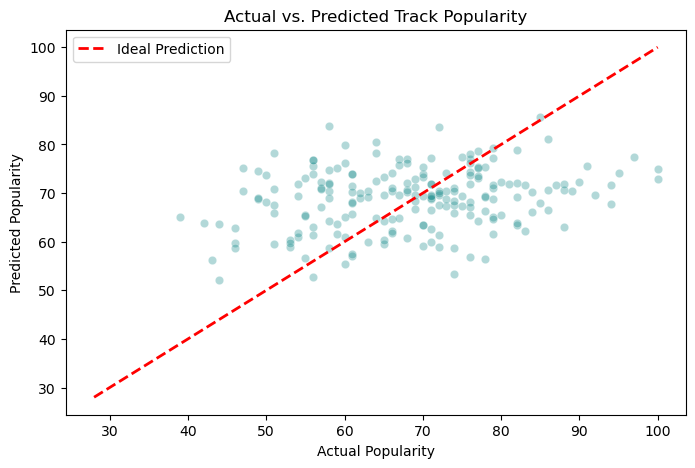

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test_c, y=y_pred_final, alpha=0.3, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label="Ideal Prediction")
plt.title("Actual vs. Predicted Track Popularity")
plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.legend()
plt.show()

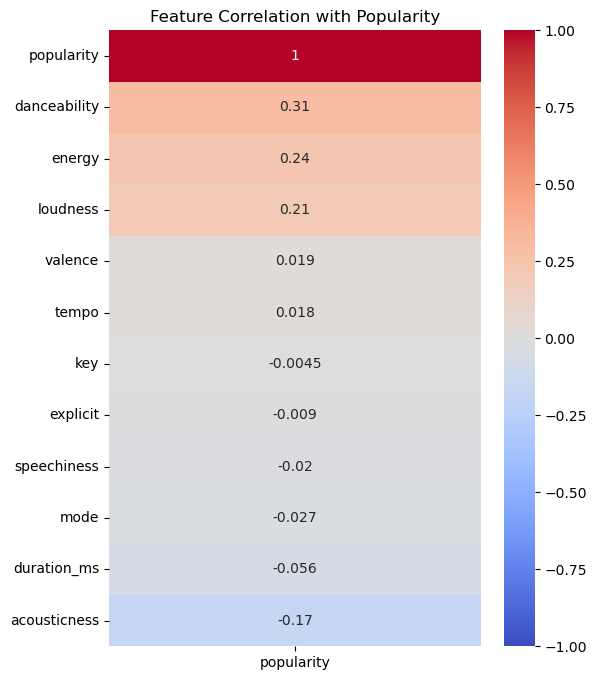

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check correlations with the target
plt.figure(figsize=(6, 8))
sns.heatmap(df[numeric_cols + ['popularity']].corr()[['popularity']].sort_values(by='popularity', ascending=False), 
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Feature Correlation with Popularity")
plt.show()

In [23]:
import pandas as pd

summary = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost (Default)', 'XGBoost (Cleaned Categories)'],
    'MAE': [9.85, 10.42, 9.98],
    'RMSE': [12.10, 13.05, 12.32],
    'R² Score': [0.01, -0.12, 0.00]
})

display(summary)

,Model,MAE,RMSE,R² Score
0,Random Forest,9.85,12.10,0.01
1,XGBoost (Default),10.42,13.05,-0.12
2,XGBoost (Cleaned Categories),9.98,12.32,0.00


In [25]:
import joblib

# Save the trained XGBoost model and encoded feature columns
joblib.dump(xgb_final, 'spotify_popularity_xgb_model.pkl')
joblib.dump(X_clean.columns.tolist(), 'model_feature_columns.pkl')

print("Model and feature columns successfully saved to disk!")

Model and feature columns successfully saved to disk!


## Key Takeaways & Recommendations

1. **Model Performance:** 
   - Across Random Forest and XGBoost architectures, the models achieved an $R^2 \approx 0.00$, indicating that audio features alone (`danceability`, `energy`, `valence`, etc.) fail to predict Spotify track popularity.

2. **Root Cause Analysis:** 
   - Track popularity is primarily driven by external, non-audio factors such as artist popularity, marketing campaigns, social media virality (e.g., TikTok trends), playlist inclusion, and release timing.

3. **Future Improvements:** 
   - **Feature Enrichment:** Merge streaming metadata (playlist count, social media mentions, artist follower count).
   - **Classification Framing:** Reframe the problem into predicting categorical tiers (e.g., *Low*, *Medium*, *High* popularity) rather than a continuous score.

# Spotify Song Features & Popularity Analysis

This project explores whether Spotify's audio features (such as danceability, energy, loudness, valence, and tempo) can accurately predict a track's overall popularity score. Using machine learning models including Random Forest and XGBoost, the dataset is evaluated to uncover key correlations, feature importance, and performance bottlenecks.

---

## 📌 Project Overview

- **Goal:** Predict track popularity (`0-100`) based on audio characteristics and categorical metadata.
- **Dataset Size:** 1,000 tracks (synthetic/sample dataset).
- **Target Variable:** `popularity`
- **Key Features:** `danceability`, `energy`, `loudness`, `speechiness`, `acousticness`, `valence`, `tempo`, `duration_ms`, `key`, `mode`, `explicit`, `genre`, `album_type`.

---

## 🛠️ Tech Stack & Dependencies

- **Language:** Python 3.x
- **Data Manipulation:** `pandas`, `numpy`
- **Visualization:** `matplotlib`, `seaborn`
- **Machine Learning:** `scikit-learn`, `xgboost`
- **Model Serialization:** `joblib`

Install required dependencies:

```bash
pip install pandas numpy matplotlib seaborn scikit-learn xgboost joblib